# A1 — Classical–quantum spectral relaxation: derivations for Section V

This notebook develops the calculations used in Section V of the manuscript.  It starts from the classical RLC generator, derives the Fokker--Planck equation from the Langevin process, constructs the Wigner Fokker--Planck equation from the Lindblad master equation, and then derives the thermal-oscillator no-crossing result and the two crossing mechanisms of the anisotropic parametric oscillator.

The final part checks the analytical results by propagating a truncated Lindblad master equation directly.  The analytical derivations and the numerical calculation are intentionally separated so that each can be inspected independently.


## 0. Notation and starting point

For the deterministic series RLC circuit we use

$$
X=\begin{pmatrix}q\\ I\end{pmatrix},
\qquad
\dot X=AX,
\qquad
A=\begin{pmatrix}
0 & 1\\[2pt]
-1/(LC) & -R/L
\end{pmatrix}.
$$

In the overdamped regime, $A$ has two real negative eigenvalues

$$
\lambda_{s,f}=\frac{-R\pm\sqrt{R^2-4L/C}}{2L},
\qquad
\lambda_f<\lambda_s<0.
$$

The deterministic state can therefore be written as

$$
X(t)=c_s v_s e^{\lambda_s t}+c_f v_f e^{\lambda_f t}.
$$

The same second-order equation describes a damped mechanical oscillator after the exact replacements

$$
m\leftrightarrow L,
\qquad
\eta\leftrightarrow R,
\qquad
k\leftrightarrow \frac1C,
\qquad
x\leftrightarrow q,
\qquad
\dot x\leftrightarrow I.
$$

The purpose of the calculations below is to see how this spectral organization changes when the state becomes a probability density and then a quantum density operator.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.sparse import csc_matrix
from scipy.sparse.linalg import expm_multiply, eigs
from scipy.linalg import expm as dense_expm
np.set_printoptions(precision=7, suppress=True)


## 1. From the Langevin process to the Fokker--Planck equation

### 1.1 Stochastic trajectory description

For additive Gaussian white noise the circuit can be written as the Itô stochastic differential equation

$$
dX_i=a_i(X)\,dt+B_{i\alpha}\,dW_\alpha,
\qquad
a_i(X)=(AX)_i.
$$

The Wiener increments satisfy

$$
\mathbb E[dW_\alpha]=0,
\qquad
\mathbb E[dW_\alpha dW_\beta]=\delta_{\alpha\beta}\,dt.
$$

The diffusion matrix is

$$
D=BB^T,
\qquad
D_{ij}=\sum_\alpha B_{i\alpha}B_{j\alpha}.
$$

The Langevin equation describes one random realization.  A different realization uses a different sequence of Wiener increments and therefore follows a different trajectory even when the initial state is the same.


### 1.2 Itô's formula and the backward generator

Let $f(X)$ be a smooth scalar function.  Itô's formula gives

$$
df
=
\partial_i f\,dX_i
+\frac12\partial_i\partial_j f\,dX_i dX_j.
$$

Substituting the stochastic increment and keeping terms through order $dt$,

$$
\begin{aligned}
df
&=\partial_i f\left(a_i\,dt+B_{i\alpha}\,dW_\alpha\right)
+\frac12\partial_i\partial_j f\,
B_{i\alpha}B_{j\beta}\,dW_\alpha dW_\beta\\[3pt]
&=\left[a_i\partial_i f+\frac12D_{ij}\partial_i\partial_j f\right]dt
+\partial_i f\,B_{i\alpha}\,dW_\alpha.
\end{aligned}
$$

Averaging over realizations removes the final stochastic term because $\mathbb E[dW_\alpha]=0$:

$$
\frac{d}{dt}\langle f\rangle
=
\left\langle
 a_i\partial_i f
 +\frac12D_{ij}\partial_i\partial_j f
\right\rangle.
$$

This defines the backward generator acting on observables,

$$
\mathcal L_{\rm FP}^{\dagger}f
=
 a_i\partial_i f
 +\frac12D_{ij}\partial_i\partial_j f.
$$


### 1.3 Moving the generator from observables to the probability density

Let $P(X,t)$ be the probability density of the stochastic state.  Ensemble averages can also be written as

$$
\langle f\rangle
=
\int f(X)P(X,t)\,dX.
$$

Differentiating with respect to time gives

$$
\frac{d}{dt}\langle f\rangle
=
\int f(X)\,\partial_tP(X,t)\,dX.
$$

For the drift term,

$$
\int a_i(\partial_i f)P\,dX
=
-\int f\,\partial_i(a_iP)\,dX,
$$

where the boundary contribution vanishes when $P$ decays sufficiently rapidly at phase-space infinity.  Integrating the diffusion contribution by parts twice gives

$$
\frac12\int D_{ij}(\partial_i\partial_jf)P\,dX
=
\frac12\int f\,\partial_i\partial_j(D_{ij}P)\,dX.
$$

For the additive-noise problem $D$ is constant, but keeping $D_{ij}$ inside the derivatives makes the adjoint structure explicit.  Since the resulting identity holds for arbitrary smooth $f$,

$$
\boxed{
\partial_tP
=
-\partial_i(a_iP)
+\frac12\partial_i\partial_j(D_{ij}P)
}.
$$

For the linear RLC drift $a(X)=AX$ and constant diffusion,

$$
\boxed{
\partial_tP
=
-\partial_i[(AX)_iP]
+\frac12D_{ij}\partial_i\partial_jP
\equiv \mathcal L_{\rm FP}P
}.
$$

This is the Fokker--Planck, or forward Kolmogorov, equation associated with the Langevin process.


### 1.4 Probability conservation

Integrating the Fokker--Planck equation over all phase space gives

$$
\frac{d}{dt}\int P\,dX
=
-\int \partial_i[(AX)_iP] \,dX
+\frac12\int D_{ij}\partial_i\partial_jP\,dX.
$$

Both terms become boundary terms.  Under the same decay assumptions used above they vanish, so

$$
\frac{d}{dt}\int P(X,t)\,dX=0.
$$

Thus the Fokker--Planck equation redistributes probability through drift and diffusion but does not create or destroy total probability.


### 1.5 First moment

Choose $f=X_k$.  Then

$$
\partial_iX_k=\delta_{ik},
\qquad
\partial_i\partial_jX_k=0.
$$

The backward-generator formula therefore gives

$$
\frac{d}{dt}\langle X_k\rangle
=
A_{ki}\langle X_i\rangle.
$$

Writing $\mu=\langle X\rangle$,

$$
\boxed{\dot\mu=A\mu}.
$$

The center of the probability distribution therefore follows exactly the same drift matrix as the deterministic circuit.


### 1.6 Second moment and covariance

Define the raw second-moment matrix

$$
M_{ij}=\langle X_iX_j\rangle.
$$

For $f=X_iX_j$,

$$
\partial_kf=\delta_{ki}X_j+\delta_{kj}X_i,
$$

and

$$
\partial_k\partial_\ell f
=\delta_{ki}\delta_{\ell j}+\delta_{kj}\delta_{\ell i}.
$$

Substitution into the backward generator gives

$$
\dot M=AM+MA^T+D.
$$

The covariance is

$$
\Sigma=M-\mu\mu^T.
$$

Because $\dot\mu=A\mu$,

$$
\frac{d}{dt}(\mu\mu^T)
=A\mu\mu^T+\mu\mu^TA^T.
$$

Subtracting this from the equation for $M$ yields

$$
\boxed{\dot\Sigma=A\Sigma+\Sigma A^T+D}.
$$

At stationarity, $\Sigma_b$ solves the continuous Lyapunov equation

$$
A\Sigma_b+\Sigma_bA^T+D=0.
$$


### 1.7 Why the covariance has three decay rates

Define the deviation from stationary covariance,

$$
\Delta\Sigma=\Sigma-\Sigma_b.
$$

The diffusion term cancels, leaving

$$
\dot{\Delta\Sigma}
=A\Delta\Sigma+\Delta\Sigma A^T.
$$

In the eigenbasis of the deterministic drift,

$$
A_m=
\begin{pmatrix}
\lambda_s&0\\
0&\lambda_f
\end{pmatrix},
\qquad
\Delta\Sigma_m=
\begin{pmatrix}
\sigma_{ss}&\sigma_{sf}\\
\sigma_{sf}&\sigma_{ff}
\end{pmatrix}.
$$

Multiplying the matrices explicitly,

$$
A_m\Delta\Sigma_m+\Delta\Sigma_mA_m^T
=
\begin{pmatrix}
2\lambda_s\sigma_{ss}&(\lambda_s+\lambda_f)\sigma_{sf}\\
(\lambda_s+\lambda_f)\sigma_{sf}&2\lambda_f\sigma_{ff}
\end{pmatrix}.
$$

Therefore

$$
\boxed{
\dot\sigma_{ss}=2\lambda_s\sigma_{ss},\qquad
\dot\sigma_{sf}=(\lambda_s+\lambda_f)\sigma_{sf},\qquad
\dot\sigma_{ff}=2\lambda_f\sigma_{ff}
}.
$$

The second-moment spectrum is built from pairwise sums of the deterministic rates.


In [2]:
# Numerical verification of the three covariance sectors.
lam_s, lam_f = -0.2, -1.1
A_m = np.diag([lam_s, lam_f])
Delta0 = np.array([[1.2, 0.35], [0.35, 0.8]])
t = np.linspace(0.0, 12.0, 300)
Delta_t = np.array([expm(A_m*tt) @ Delta0 @ expm(A_m.T*tt) for tt in t])

assert np.allclose(Delta_t[:,0,0], Delta0[0,0]*np.exp(2*lam_s*t))
assert np.allclose(Delta_t[:,0,1], Delta0[0,1]*np.exp((lam_s+lam_f)*t))
assert np.allclose(Delta_t[:,1,1], Delta0[1,1]*np.exp(2*lam_f*t))
print('Covariance-sector rates verified.')


Covariance-sector rates verified.


## 2. From a Lindblad master equation to a Wigner Fokker--Planck equation

### 2.1 Lindblad evolution

For a Markovian quantum system,

$$
\dot\rho
=-\frac{i}{\hbar}[H,\rho]
+\sum_j\gamma_j
\left(
L_j\rho L_j^\dagger
-\frac12\{L_j^\dagger L_j,\rho\}
\right)
\equiv\mathcal L\rho.
$$

For the thermal harmonic oscillator,

$$
H_0=\hbar\omega a^\dagger a,
$$

and

$$
\dot\rho
=-i[\omega a^\dagger a,\rho]
+\kappa(\bar n+1)\mathcal D[a]\rho
+\kappa\bar n\mathcal D[a^\dagger]\rho.
$$

The dimensionless quadratures are

$$
x=\frac{a+a^\dagger}{\sqrt2},
\qquad
p=\frac{a-a^\dagger}{i\sqrt2},
\qquad
[x,p]=i.
$$


### 2.2 Wigner function and left/right operator action

With $[x,p]=i$, one convenient convention for the Wigner function is

$$
W(x,p)
=
\frac{1}{2\pi}
\int_{-\infty}^{\infty}
 e^{ipy}
\left\langle x-\frac y2\middle|\rho\middle|x+\frac y2\right\rangle
\,dy,
$$

with normalization

$$
\int W(x,p)\,dx\,dp=1.
$$

The left and right actions of the quadrature operators are not identical.  From the definition above one obtains

$$
\begin{aligned}
x\rho &\leftrightarrow \left(x+\frac{i}{2}\partial_p\right)W,
&\rho x &\leftrightarrow \left(x-\frac{i}{2}\partial_p\right)W,\\[3pt]
p\rho &\leftrightarrow \left(p-\frac{i}{2}\partial_x\right)W,
&\rho p &\leftrightarrow \left(p+\frac{i}{2}\partial_x\right)W.
\end{aligned}
$$

For example,

$$
\begin{aligned}
\mathcal W[x\rho]
&=\frac{1}{2\pi}\int e^{ipy}
\left(x-\frac y2\right)
\left\langle x-\frac y2\middle|\rho\middle|x+\frac y2\right\rangle dy\\[3pt]
&=xW+\frac{i}{2}\partial_pW.
\end{aligned}
$$

The derivative term therefore comes directly from the difference between left and right multiplication inside the density matrix.


### 2.3 Ladder-operator correspondences

Define

$$
\alpha=\frac{x+ip}{\sqrt2},
\qquad
\alpha^*=\frac{x-ip}{\sqrt2},
$$

and

$$
\partial_\alpha
=\frac{1}{\sqrt2}(\partial_x-i\partial_p),
\qquad
\partial_{\alpha^*}
=\frac{1}{\sqrt2}(\partial_x+i\partial_p).
$$

Using $a=(x+ip)/\sqrt2$ and $a^\dagger=(x-ip)/\sqrt2$ gives the four standard Wigner correspondences

$$
\boxed{
\begin{aligned}
a\rho &\leftrightarrow
\left(\alpha+\frac12\partial_{\alpha^*}\right)W,
&\rho a &\leftrightarrow
\left(\alpha-\frac12\partial_{\alpha^*}\right)W,\\[3pt]
a^\dagger\rho &\leftrightarrow
\left(\alpha^*-\frac12\partial_\alpha\right)W,
&\rho a^\dagger &\leftrightarrow
\left(\alpha^*+\frac12\partial_\alpha\right)W.
\end{aligned}
}
$$

These rules are enough to transform every term of the thermal Lindblad equation.


### 2.4 Hamiltonian term

For $H_0=\hbar\omega a^\dagger a$,

$$
-i[\omega a^\dagger a,\rho]
$$

contains the difference between left and right number-operator multiplication.  Applying the ladder-operator rules and simplifying gives

$$
-i[\omega a^\dagger a,\rho]
\leftrightarrow
 i\omega\left[
 \partial_\alpha(\alpha W)
 -\partial_{\alpha^*}(\alpha^*W)
 \right].
$$

Using the derivative relations above,

$$
\boxed{
-i[\omega a^\dagger a,\rho]
\leftrightarrow
-\partial_x(\omega p\,W)
-\partial_p(-\omega x\,W)
}.
$$

Thus the Hamiltonian rotates the Wigner function in phase space without diffusion.


### 2.5 Loss dissipator $\mathcal D[a]$

The three terms in

$$
\mathcal D[a]\rho
=a\rho a^\dagger
-\frac12a^\dagger a\rho
-\frac12\rho a^\dagger a
$$

can be generated by composing the left/right correspondence rules.  Explicitly,

$$
\begin{aligned}
a\rho a^\dagger
&\leftrightarrow
\left(\alpha^*+\frac12\partial_\alpha\right)
\left(\alpha+\frac12\partial_{\alpha^*}\right)W,\\[3pt]
a^\dagger a\rho
&\leftrightarrow
\left(\alpha^*-\frac12\partial_\alpha\right)
\left(\alpha+\frac12\partial_{\alpha^*}\right)W,\\[3pt]
\rho a^\dagger a
&\leftrightarrow
\left(\alpha-\frac12\partial_{\alpha^*}\right)
\left(\alpha^*+\frac12\partial_\alpha\right)W.
\end{aligned}
$$

After expanding the derivatives and combining terms,

$$
\boxed{
\mathcal D[a]\rho
\leftrightarrow
\frac12\left[
\partial_\alpha(\alpha W)
+\partial_{\alpha^*}(\alpha^*W)
+\partial_\alpha\partial_{\alpha^*}W
\right]
}.
$$


### 2.6 Excitation dissipator $\mathcal D[a^\dagger]$

Similarly,

$$
\mathcal D[a^\dagger]\rho
=a^\dagger\rho a
-\frac12aa^\dagger\rho
-\frac12\rho aa^\dagger
$$

becomes

$$
\boxed{
\mathcal D[a^\dagger]\rho
\leftrightarrow
\frac12\left[
-\partial_\alpha(\alpha W)
-\partial_{\alpha^*}(\alpha^*W)
+\partial_\alpha\partial_{\alpha^*}W
\right]
}.
$$

The drift part changes sign relative to $\mathcal D[a]$, while the diffusion part has the same sign.


### 2.7 Combining the two thermal dissipators

Multiply the loss and excitation terms by their thermal rates:

$$
\kappa(\bar n+1)\mathcal D[a]
+\kappa\bar n\mathcal D[a^\dagger].
$$

The drift coefficient is proportional to

$$
(\bar n+1)-\bar n=1,
$$

whereas the diffusion coefficient is proportional to

$$
(\bar n+1)+\bar n=2\bar n+1=2\nu_b,
\qquad
\nu_b=\bar n+\frac12.
$$

Therefore

$$
\begin{aligned}
&\kappa(\bar n+1)\mathcal D[a]\rho
+\kappa\bar n\mathcal D[a^\dagger]\rho\\[3pt]
&\qquad\leftrightarrow
\frac\kappa2
\left[
\partial_\alpha(\alpha W)
+\partial_{\alpha^*}(\alpha^*W)
\right]
+\kappa\nu_b\partial_\alpha\partial_{\alpha^*}W.
\end{aligned}
$$

Since

$$
\partial_\alpha(\alpha W)+\partial_{\alpha^*}(\alpha^*W)
=\partial_x(xW)+\partial_p(pW),
$$

and

$$
\partial_\alpha\partial_{\alpha^*}
=\frac12(\partial_x^2+\partial_p^2),
$$

the thermal dissipator becomes

$$
\boxed{
\frac\kappa2\left[\partial_x(xW)+\partial_p(pW)\right]
+\frac{\kappa\nu_b}{2}(\partial_x^2+\partial_p^2)W
}.
$$


### 2.8 Thermal Wigner Fokker--Planck equation

Adding Hamiltonian rotation and thermal dissipation gives

$$
\boxed{
\begin{aligned}
\partial_tW
={}&-\partial_x\left[\left(-\frac\kappa2x+\omega p\right)W\right]
-\partial_p\left[\left(-\omega x-\frac\kappa2p\right)W\right]\\[3pt]
&+\frac{\kappa\nu_b}{2}
(\partial_x^2+\partial_p^2)W.
\end{aligned}
}
$$

Writing $R=(x,p)^T$, this has the Ornstein--Uhlenbeck form

$$
\partial_tW
=-\partial_i[(A_0R)_iW]
+\frac12(D_0)_{ij}\partial_i\partial_jW,
$$

with

$$
\boxed{
A_0=-\frac\kappa2I+\omega J,
\qquad
J=\begin{pmatrix}0&1\\-1&0\end{pmatrix},
\qquad
D_0=\kappa\nu_bI
}.
$$

The matrix moment equations are consequently

$$
\boxed{
\dot\mu=A_0\mu,
\qquad
\dot V=A_0V+VA_0^T+D_0
}.
$$


### 2.9 What is the same and what is different from the classical probability density

The linear algebra of the Gaussian moment equations is the same as for a classical Ornstein--Uhlenbeck process, but the state spaces are not identical.  A classical probability density is nonnegative.  A Wigner function is a quasiprobability and can become negative for non-Gaussian quantum states.

The quantum covariance must also satisfy the Robertson--Schrödinger condition

$$
\boxed{V+\frac{i}{2}\Omega\ge0},
\qquad
\Omega=\begin{pmatrix}0&1\\-1&0\end{pmatrix}.
$$

For one mode this implies

$$
\det V\ge\frac14.
$$


In [3]:
# Thermal oscillator: verify the stationary covariance.
kappa = 1.0
omega = 1.7
nbar = 0.8
nu_b = nbar + 0.5
J = np.array([[0.0, 1.0], [-1.0, 0.0]])
A0 = -0.5*kappa*np.eye(2) + omega*J
D0 = kappa*nu_b*np.eye(2)
Vb = nu_b*np.eye(2)
print('Lyapunov residual =')
print(A0@Vb + Vb@A0.T + D0)
assert np.allclose(A0@Vb + Vb@A0.T + D0, 0.0)


Lyapunov residual =
[[0. 0.]
 [0. 0.]]


## 3. Thermal oscillator: why the mean bare-energy ordering cannot cross

### 3.1 First moments

Because $A_0=-\kappa I/2+\omega J$ and $I$ commutes with $J$,

$$
e^{A_0t}
=e^{-\kappa t/2}e^{\omega Jt}
=e^{-\kappa t/2}\mathcal R(\omega t),
$$

where $\mathcal R$ is a rotation matrix.  Hence

$$
\boxed{\mu(t)=e^{-\kappa t/2}\mathcal R(\omega t)\mu(0)}.
$$

The squared displacement therefore obeys

$$
\mu^T(t)\mu(t)=e^{-\kappa t}\mu^T(0)\mu(0).
$$


### 3.2 Covariance deviation

Let

$$
\Delta V=V-V_b,
\qquad
V_b=\nu_bI.
$$

Since $V_b$ solves the stationary Lyapunov equation,

$$
\dot{\Delta V}=A_0\Delta V+\Delta V A_0^T.
$$

Thus

$$
\Delta V(t)
=e^{A_0t}\Delta V(0)e^{A_0^Tt}
=e^{-\kappa t}\mathcal R(\omega t)\Delta V(0)\mathcal R^T(\omega t).
$$

Taking the trace and using cyclic invariance,

$$
\boxed{\operatorname{Tr}\Delta V(t)
=e^{-\kappa t}\operatorname{Tr}\Delta V(0)}.
$$


### 3.3 Bare energy

For

$$
H_0=\hbar\omega\left(a^\dagger a+\frac12\right)
=\frac{\hbar\omega}{2}(x^2+p^2),
$$

the mean energy is

$$
\langle H_0\rangle
=\frac{\hbar\omega}{2}
\left(\mu^T\mu+\operatorname{Tr}V\right).
$$

Subtracting the bath value,

$$
\Delta E(t)
=\frac{\hbar\omega}{2}
\left[
\mu^T(t)\mu(t)+\operatorname{Tr}\Delta V(t)
\right].
$$

Both terms have the same factor $e^{-\kappa t}$, so

$$
\boxed{\Delta E(t)=e^{-\kappa t}\Delta E(0)}.
$$

For two preparations,

$$
\boxed{
E_1(t)-E_2(t)
=e^{-\kappa t}[E_1(0)-E_2(0)]
}.
$$

The sign of the energy difference cannot change.


### 3.4 The no-crossing result is not restricted to Gaussian states

The previous derivation used Gaussian moment equations, but the energy law follows directly from the master equation.  For any observable $O$,

$$
\frac{d}{dt}\langle O\rangle
=\langle\mathcal L^\dagger O\rangle.
$$

For a dissipator,

$$
\mathcal D^\dagger[L]O
=L^\dagger O L
-\frac12\{L^\dagger L,O\}.
$$

Take $O=n=a^\dagger a$.  Using $na=a(n-1)$,

$$
a^\dagger n a
=a^\dagger a(n-1)
=n(n-1),
$$

so

$$
\mathcal D^\dagger[a]n
=n(n-1)-n^2=-n.
$$

Similarly, using $aa^\dagger=n+1$,

$$
\mathcal D^\dagger[a^\dagger]n=n+1.
$$

The thermal master equation therefore gives

$$
\begin{aligned}
\frac{d}{dt}\langle n\rangle
&=\kappa(\bar n+1)(-\langle n\rangle)
+\kappa\bar n(\langle n\rangle+1)\\[3pt]
&=-\kappa(\langle n\rangle-\bar n).
\end{aligned}
$$

Hence

$$
\boxed{
\langle n(t)\rangle-\bar n
=e^{-\kappa t}[\langle n(0)\rangle-\bar n]
}.
$$

The mean bare-energy ordering is therefore preserved for any initial state with finite mean occupation under this thermal generator.


In [4]:
# Direct Gaussian-moment verification of the single energy envelope.
mu0 = np.array([1.1, -0.3])
V0 = np.array([[2.4, 0.2], [0.2, 1.1]])
t = np.linspace(0.0, 6.0, 250)
dE0 = 0.5*(mu0@mu0 + np.trace(V0 - Vb))
dE = []
for tt in t:
    P = expm(A0*tt)
    mu = P@mu0
    DV = P@(V0-Vb)@P.T
    dE.append(0.5*(mu@mu + np.trace(DV)))
dE = np.asarray(dE)
assert np.allclose(dE, dE0*np.exp(-kappa*t), rtol=2e-10, atol=2e-10)
print('Thermal-QHO single energy envelope verified.')


Thermal-QHO single energy envelope verified.


## 4. Parametric oscillator: restoring distinct slow and fast quadratures

### 4.1 Parametric Hamiltonian in quadrature form

In the rotating frame consider

$$
H_\epsilon
=\frac{i\hbar\epsilon}{2}(a^{\dagger2}-a^2).
$$

With

$$
a=\frac{x+ip}{\sqrt2},
\qquad
a^\dagger=\frac{x-ip}{\sqrt2},
$$

one finds

$$
a^{\dagger2}-a^2=-i(xp+px),
$$

so

$$
\boxed{H_\epsilon=\frac{\hbar\epsilon}{2}(xp+px)}.
$$

The Heisenberg equations are

$$
\dot x=\frac{i}{\hbar}[H_\epsilon,x],
\qquad
\dot p=\frac{i}{\hbar}[H_\epsilon,p].
$$

Using $[x,p]=i$,

$$
[xp+px,x]=-2ix,
\qquad
[xp+px,p]=2ip,
$$

and therefore

$$
\boxed{\dot x=\epsilon x,\qquad \dot p=-\epsilon p}.
$$


### 4.2 Add thermal damping and diffusion

Thermal damping contributes $-\kappa x/2$ and $-\kappa p/2$ to the first moments.  The two quadratures therefore obey

$$
\dot x=\left(-\frac\kappa2+\epsilon\right)x,
\qquad
\dot p=\left(-\frac\kappa2-\epsilon\right)p.
$$

Define

$$
\boxed{
\lambda_s=-\frac\kappa2+\epsilon,
\qquad
\lambda_f=-\frac\kappa2-\epsilon
}.
$$

The stable below-threshold regime is

$$
0<\epsilon<\frac\kappa2,
$$

so both rates remain negative.

The Wigner equation is

$$
\boxed{
\begin{aligned}
\partial_tW
={}&-\partial_x(\lambda_s xW)
-\partial_p(\lambda_f pW)\\[3pt]
&+\frac{\kappa\nu_b}{2}(\partial_x^2+\partial_p^2)W.
\end{aligned}
}
$$

Hence

$$
A_\epsilon=\begin{pmatrix}\lambda_s&0\\0&\lambda_f\end{pmatrix},
\qquad
D_\epsilon=\kappa\nu_bI.
$$


### 4.3 Stationary covariance

Let

$$
V_{\rm ss}=\begin{pmatrix}v_x&c\\c&v_p\end{pmatrix}.
$$

The stationary Lyapunov equation

$$
A_\epsilon V_{\rm ss}+V_{\rm ss}A_\epsilon^T+D_\epsilon=0
$$

gives three scalar equations:

$$
2\lambda_s v_x+\kappa\nu_b=0,
$$

$$
(\lambda_s+\lambda_f)c=0,
$$

and

$$
2\lambda_f v_p+\kappa\nu_b=0.
$$

Since $\lambda_s+\lambda_f=-\kappa\neq0$, $c=0$.  Therefore

$$
\boxed{
V_{\rm ss}
=\nu_b
\begin{pmatrix}
\dfrac{\kappa}{\kappa-2\epsilon}&0\\[8pt]
0&\dfrac{\kappa}{\kappa+2\epsilon}
\end{pmatrix}
}.
$$

Its determinant is

$$
\det V_{\rm ss}
=\nu_b^2\frac{\kappa^2}{\kappa^2-4\epsilon^2}
\ge\nu_b^2\ge\frac14,
$$

so the stationary covariance satisfies the one-mode uncertainty condition throughout the stable regime.


In [5]:
# Numerical stationary-covariance check.
kappa = 1.0
eps = 0.18
nbar = 0.15
nu_b = nbar + 0.5
lam_s = -kappa/2 + eps
lam_f = -kappa/2 - eps
Aeps = np.diag([lam_s, lam_f])
Deps = kappa*nu_b*np.eye(2)
Vss = nu_b*np.diag([kappa/(kappa-2*eps), kappa/(kappa+2*eps)])
assert np.allclose(Aeps@Vss + Vss@Aeps.T + Deps, 0.0)
assert np.linalg.det(Vss) >= 0.25
print('lambda_s, lambda_f =', lam_s, lam_f)
print('V_ss =\n', Vss)
print('det(V_ss) =', np.linalg.det(Vss))


lambda_s, lambda_f = -0.32 -0.6799999999999999
V_ss =
 [[1.015625  0.       ]
 [0.        0.4779412]]
det(V_ss) = 0.4854090073529412


### 4.4 Displacement-controlled crossing

Keep the covariance fixed at $V_{\rm ss}$ and prepare one state displaced only along the slow quadrature and another displaced only along the fast quadrature.  Their means evolve as

$$
\mu_s(t)=\mu_s(0)e^{\lambda_st},
\qquad
\mu_f(t)=\mu_f(0)e^{\lambda_ft}.
$$

For a fixed covariance, the excess bare energy carried by the displacement is proportional to the squared displacement:

$$
\Delta E_{\mu,s}(t)
=\Delta E_{\mu,s}(0)e^{2\lambda_st},
$$

$$
\Delta E_{\mu,f}(t)
=\Delta E_{\mu,f}(0)e^{2\lambda_ft}.
$$

At the crossing,

$$
\Delta E_{\mu,s}(0)e^{2\lambda_st_\times}
=
\Delta E_{\mu,f}(0)e^{2\lambda_ft_\times}.
$$

Taking logarithms,

$$
2(\lambda_s-\lambda_f)t_\times
=
\ln\frac{\Delta E_{\mu,f}(0)}{\Delta E_{\mu,s}(0)}.
$$

Since $\lambda_s-\lambda_f=2\epsilon$,

$$
\boxed{
 t_\times^{(\mu)}
=\frac{1}{4\epsilon}
\ln\frac{\Delta E_{\mu,f}(0)}{\Delta E_{\mu,s}(0)}
}.
$$


### 4.5 Covariance-controlled crossing

Now set the first moments to zero and place the excess covariance along one quadrature:

$$
\Delta V_s(0)=\delta_s
\begin{pmatrix}1&0\\0&0\end{pmatrix},
\qquad
\Delta V_f(0)=\delta_f
\begin{pmatrix}0&0\\0&1\end{pmatrix}.
$$

The covariance deviation obeys

$$
\Delta V(t)=e^{A_\epsilon t}\Delta V(0)e^{A_\epsilon^Tt}.
$$

Therefore

$$
\Delta V_s(t)=\delta_s e^{2\lambda_st}
\begin{pmatrix}1&0\\0&0\end{pmatrix},
$$

and

$$
\Delta V_f(t)=\delta_f e^{2\lambda_ft}
\begin{pmatrix}0&0\\0&1\end{pmatrix}.
$$

The excess bare energy carried by the covariance is proportional to $\operatorname{Tr}\Delta V$, giving

$$
\Delta E_{V,s}(t)=\Delta E_{V,s}(0)e^{2\lambda_st},
$$

$$
\Delta E_{V,f}(t)=\Delta E_{V,f}(0)e^{2\lambda_ft}.
$$

Thus

$$
\boxed{
 t_\times^{(V)}
=\frac{\ln[\Delta E_{V,s}(0)/\Delta E_{V,f}(0)]}
{2(\lambda_f-\lambda_s)}
}.
$$

When the fast preparation begins with the larger energy, this is again positive because $\lambda_f-\lambda_s<0$.


### 4.6 A dynamical mode can be invisible to the energy

For a general covariance deviation,

$$
\Delta V=
\begin{pmatrix}
v_{ss}&v_{sf}\\
v_{sf}&v_{ff}
\end{pmatrix},
$$

the three sectors evolve as

$$
v_{ss}(t)\propto e^{2\lambda_st},
\qquad
v_{sf}(t)\propto e^{(\lambda_s+\lambda_f)t}=e^{-\kappa t},
\qquad
v_{ff}(t)\propto e^{2\lambda_ft}.
$$

The bare energy depends on

$$
\operatorname{Tr}V=v_{ss}+v_{ff},
$$

so the mixed sector $v_{sf}$ does not contribute.  It is a genuine decay sector of the state but is invisible to this observable.


In [6]:
# Analytic crossing examples and invisible mixed sector.
Eslow0 = 0.10
Efast0 = 1.00
tx_mu = np.log(Efast0/Eslow0)/(4*eps)

delta_s = 0.20
delta_f = 2.00
EVslow0 = 0.5*delta_s
EVfast0 = 0.5*delta_f
tx_V = np.log(EVslow0/EVfast0)/(2*(lam_f-lam_s))

Dmix = np.array([[0.0, 1.0], [1.0, 0.0]])
test_t = np.linspace(0.0, 5.0, 100)
traces = []
offdiag = []
for tt in test_t:
    P = expm(Aeps*tt)
    DV = P@Dmix@P.T
    traces.append(np.trace(DV))
    offdiag.append(DV[0,1])
assert np.allclose(traces, 0.0)
assert np.allclose(offdiag, np.exp(-kappa*test_t))
print('analytic displacement crossing =', tx_mu)
print('analytic covariance crossing   =', tx_V)
print('mixed covariance sector is invisible to bare energy: verified')


analytic displacement crossing = 3.1980348513806196
analytic covariance crossing   = 3.198034851380619
mixed covariance sector is invisible to bare energy: verified


## 5. Physical Gaussian preparations

A diagonal one-mode covariance

$$
V=\operatorname{diag}(v_x,v_p)
$$

can be represented as a squeezed thermal state when $v_xv_p\ge1/4$.  Define

$$
\nu=\sqrt{v_xv_p},
\qquad
\bar n_{\rm eff}=\nu-\frac12,
\qquad
r=\frac14\ln\frac{v_p}{v_x}.
$$

For the squeezing operator $S(r)$,

$$
S^\dagger(r)xS(r)=e^{-r}x,
\qquad
S^\dagger(r)pS(r)=e^{r}p.
$$

Starting from a thermal covariance $\nu I$ therefore gives

$$
V=
u\operatorname{diag}(e^{-2r},e^{2r}),
$$

which reproduces the target $v_x$ and $v_p$ by construction.  This representation is used below to prepare covariance-controlled initial states directly in Hilbert space.


In [7]:
def one_mode_physical(V, tol=1e-12):
    return np.linalg.det(V) >= 0.25 - tol and np.all(np.linalg.eigvalsh(V) > 0)

Vs_target = Vss + np.diag([delta_s, 0.0])
Vf_target = Vss + np.diag([0.0, delta_f])
assert one_mode_physical(Vss)
assert one_mode_physical(Vs_target)
assert one_mode_physical(Vf_target)
print('All stationary and prepared covariances satisfy det(V) >= 1/4.')


All stationary and prepared covariances satisfy det(V) >= 1/4.


## 6. Direct master-equation validation

The previous results used Gaussian drift and covariance equations.  We now check them without using those moment equations.

For column-stacking vectorization,

$$
\operatorname{vec}(A\rho B)
=(B^T\otimes A)\operatorname{vec}(\rho).
$$

The Hamiltonian part therefore becomes

$$
-i[H,\rho]
\longrightarrow
-i(I\otimes H-H^T\otimes I)\operatorname{vec}(\rho),
$$

and a dissipator becomes

$$
\mathcal D[L]
\longrightarrow
L^*\otimes L
-\frac12I\otimes L^\dagger L
-\frac12(L^\dagger L)^T\otimes I.
$$

The code below constructs this Liouvillian matrix in a truncated Fock basis, finds its stationary density matrix, prepares displaced and squeezed states, and propagates the density matrices directly.


In [8]:
def destroy(N):
    a = np.zeros((N,N), complex)
    for n in range(1,N):
        a[n-1,n] = np.sqrt(n)
    return a

def dissipator_super(L):
    N = L.shape[0]
    I = np.eye(N)
    K = L.conj().T @ L
    return np.kron(L.conj(), L) - 0.5*np.kron(I, K) - 0.5*np.kron(K.T, I)

def liouvillian(H, collapse_ops):
    N = H.shape[0]
    I = np.eye(N)
    S = -1j*(np.kron(I,H) - np.kron(H.T,I))
    for c in collapse_ops:
        S += dissipator_super(c)
    return csc_matrix(S)

def mat(v,N):
    return np.asarray(v).reshape((N,N), order='F')

def vec(rho):
    return np.asarray(rho).reshape(-1, order='F')

def hermitize(rho):
    return (rho + rho.conj().T)/2

def moments(rho,a):
    adag = a.conj().T
    x = (a+adag)/np.sqrt(2)
    p = (a-adag)/(1j*np.sqrt(2))
    n = adag@a
    mx = np.trace(rho@x).real
    mp = np.trace(rho@p).real
    vx = np.trace(rho@(x@x)).real - mx**2
    vp = np.trace(rho@(p@p)).real - mp**2
    xp = 0.5*np.trace(rho@(x@p+p@x)).real - mx*mp
    V = np.array([[vx,xp],[xp,vp]])
    Ebare_over_hw = np.trace(rho@n).real + 0.5
    return np.array([mx,mp]), V, Ebare_over_hw

def thermal_state(N,nbar):
    r = nbar/(nbar+1) if nbar>0 else 0.0
    probs = (1-r)*r**np.arange(N)
    probs = probs/probs.sum()
    return np.diag(probs.astype(complex))

def gaussian_diag_state(N,vx,vp,a):
    nu = np.sqrt(vx*vp)
    nth = max(nu-0.5, 0.0)
    r = 0.25*np.log(vp/vx)
    rho = thermal_state(N,nth)
    adag = a.conj().T
    S = dense_expm(0.5*r*(a@a-adag@adag))
    return hermitize(S@rho@S.conj().T)

def displace(rho,a,alpha):
    adag = a.conj().T
    D = dense_expm(alpha*adag-alpha.conjugate()*a)
    return hermitize(D@rho@D.conj().T)

def first_crossing(t,y):
    idx = np.where(y[:-1]*y[1:] <= 0)[0]
    if len(idx)==0:
        return np.nan
    i = idx[0]
    return t[i] - y[i]*(t[i+1]-t[i])/(y[i+1]-y[i])


### 6.1 Stationary state from the Liouvillian

For the parametric oscillator the Hamiltonian and collapse operators are

$$
H_\epsilon=\frac{i\epsilon}{2}(a^{\dagger2}-a^2),
$$

$$
C_1=\sqrt{\kappa(\bar n+1)}\,a,
\qquad
C_2=\sqrt{\kappa\bar n}\,a^\dagger.
$$

The stationary state is the right eigenvector of the Liouvillian with eigenvalue closest to zero.  Its quadrature covariance should approach the analytical $V_{\rm ss}$ as the Fock cutoff is increased.


In [9]:
N = 18
a = destroy(N)
adag = a.conj().T
H = 1j*eps/2*(adag@adag-a@a)
collapse_ops = [np.sqrt(kappa*(nbar+1))*a, np.sqrt(kappa*nbar)*adag]
Lsup = liouvillian(H, collapse_ops)

val, vr = eigs(Lsup, k=1, sigma=0)
rho_ss = hermitize(mat(vr[:,0], N))
rho_ss = rho_ss/np.trace(rho_ss)
mu_num, V_num, E_ss = moments(rho_ss, a)
print('stationary mean =', mu_num)
print('stationary covariance =\n', V_num)
print('analytical covariance =\n', Vss)
assert np.max(np.abs(V_num-Vss)) < 0.04


stationary mean = [-0. -0.]
stationary covariance =
 [[ 1.0156247 -0.       ]
 [-0.         0.4779413]]
analytical covariance =
 [[1.015625  0.       ]
 [0.        0.4779412]]


### 6.2 Direct displacement-controlled crossing

Choose a slow displacement along $x$ and a fast displacement along $p$.  The initial covariance is the stationary covariance in both cases, so the energy difference comes only from the first moments.  The analytical crossing time is the expression derived in Sec. 4.4.


In [10]:
numop = adag@a
rho_s = displace(rho_ss, a, np.sqrt(Eslow0)+0j)
rho_f = displace(rho_ss, a, 1j*np.sqrt(Efast0))

tgrid_mu = np.linspace(0.0, 1.6*tx_mu, 100)
Rs = expm_multiply(Lsup, vec(rho_s), start=0, stop=tgrid_mu[-1], num=len(tgrid_mu), endpoint=True)
Rf = expm_multiply(Lsup, vec(rho_f), start=0, stop=tgrid_mu[-1], num=len(tgrid_mu), endpoint=True)

Es_num=[]
Ef_num=[]
for vs,vf in zip(Rs,Rf):
    rs = hermitize(mat(vs,N))
    rf = hermitize(mat(vf,N))
    Es_num.append(np.trace(rs@numop).real + 0.5 - E_ss)
    Ef_num.append(np.trace(rf@numop).real + 0.5 - E_ss)
Es_num=np.asarray(Es_num)
Ef_num=np.asarray(Ef_num)
tx_mu_num = first_crossing(tgrid_mu, Ef_num-Es_num)
print('displacement crossing: analytic =', tx_mu, ' direct master equation =', tx_mu_num)
assert abs(tx_mu_num-tx_mu)/tx_mu < 0.07


displacement crossing: analytic = 3.1980348513806196  direct master equation = 3.1983312878968997


### 6.3 Direct covariance-controlled crossing

Now prepare centered Gaussian states whose covariances are $V_{\rm ss}+\Delta V_s$ and $V_{\rm ss}+\Delta V_f$.  No displacement is added.  The energy-order inversion therefore comes entirely from the covariance sector.


In [11]:
rho_Vs = gaussian_diag_state(N, Vs_target[0,0], Vs_target[1,1], a)
rho_Vf = gaussian_diag_state(N, Vf_target[0,0], Vf_target[1,1], a)
_, Vs_num, _ = moments(rho_Vs,a)
_, Vf_num, _ = moments(rho_Vf,a)
print('prepared covariance, slow state =\n', Vs_num)
print('prepared covariance, fast state =\n', Vf_num)

tgrid_V = np.linspace(0.0, 1.6*tx_V, 100)
RsV = expm_multiply(Lsup, vec(rho_Vs), start=0, stop=tgrid_V[-1], num=len(tgrid_V), endpoint=True)
RfV = expm_multiply(Lsup, vec(rho_Vf), start=0, stop=tgrid_V[-1], num=len(tgrid_V), endpoint=True)
EsV_num=[]
EfV_num=[]
for vs,vf in zip(RsV,RfV):
    rs = hermitize(mat(vs,N))
    rf = hermitize(mat(vf,N))
    EsV_num.append(np.trace(rs@numop).real + 0.5 - E_ss)
    EfV_num.append(np.trace(rf@numop).real + 0.5 - E_ss)
EsV_num=np.asarray(EsV_num)
EfV_num=np.asarray(EfV_num)
tx_V_num = first_crossing(tgrid_V, EfV_num-EsV_num)
print('covariance crossing: analytic =', tx_V, ' direct master equation =', tx_V_num)
assert abs(tx_V_num-tx_V)/tx_V < 0.12


prepared covariance, slow state =
 [[1.2156238 0.       ]
 [0.        0.4779415]]
prepared covariance, fast state =
 [[1.017906  0.       ]
 [0.        2.4715223]]


covariance crossing: analytic =

 3.198034851380619  direct master equation = 3.2152655422770824


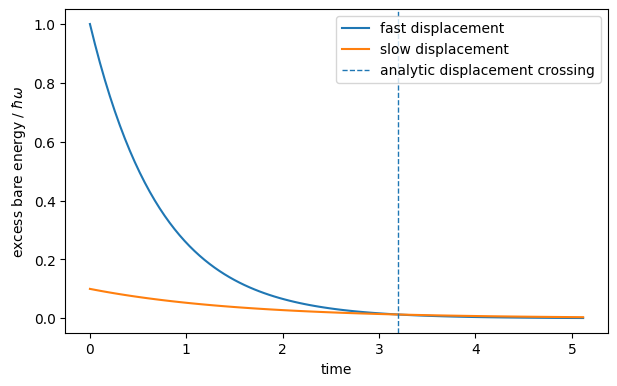

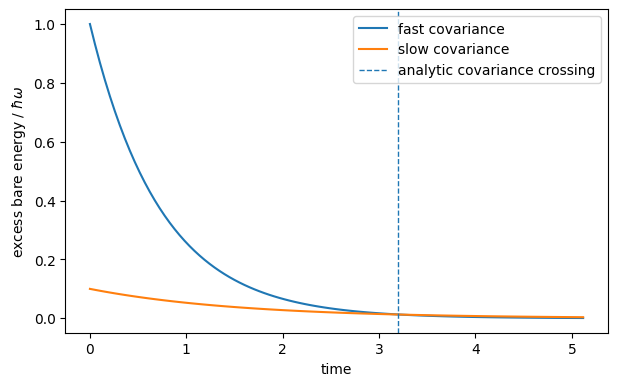

In [12]:
# Visual comparison of the two direct master-equation crossings.
fig, ax = plt.subplots(figsize=(7.0,4.2))
ax.plot(tgrid_mu, Ef_num, label='fast displacement')
ax.plot(tgrid_mu, Es_num, label='slow displacement')
ax.axvline(tx_mu, ls='--', lw=1, label='analytic displacement crossing')
ax.set_xlabel('time')
ax.set_ylabel(r'excess bare energy / $\hbar\omega$')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7.0,4.2))
ax.plot(tgrid_V, EfV_num, label='fast covariance')
ax.plot(tgrid_V, EsV_num, label='slow covariance')
ax.axvline(tx_V, ls='--', lw=1, label='analytic covariance crossing')
ax.set_xlabel('time')
ax.set_ylabel(r'excess bare energy / $\hbar\omega$')
ax.legend()
plt.show()


### 6.4 Fock-cutoff convergence

A finite Fock basis is an approximation.  The stationary covariance and both crossing times should stabilize as the cutoff is increased.  The calculation below repeats the full construction for several cutoffs rather than checking only one chosen Hilbert-space dimension.


In [13]:
def crossings_at_cutoff(Ncut, points=70):
    aN = destroy(Ncut)
    adagN = aN.conj().T
    HN = 1j*eps/2*(adagN@adagN-aN@aN)
    copsN = [np.sqrt(kappa*(nbar+1))*aN, np.sqrt(kappa*nbar)*adagN]
    LN = liouvillian(HN, copsN)
    _, vrN = eigs(LN, k=1, sigma=0)
    rssN = hermitize(mat(vrN[:,0], Ncut))
    rssN = rssN/np.trace(rssN)
    _, VN, EssN = moments(rssN, aN)
    nN = adagN@aN

    rho_sN = displace(rssN, aN, np.sqrt(Eslow0)+0j)
    rho_fN = displace(rssN, aN, 1j*np.sqrt(Efast0))
    tg_mu = np.linspace(0.0, 1.6*tx_mu, points)
    RsN = expm_multiply(LN, vec(rho_sN), start=0, stop=tg_mu[-1], num=len(tg_mu), endpoint=True)
    RfN = expm_multiply(LN, vec(rho_fN), start=0, stop=tg_mu[-1], num=len(tg_mu), endpoint=True)
    diff_mu=[]
    for vs,vf in zip(RsN,RfN):
        es = np.trace(hermitize(mat(vs,Ncut))@nN).real + 0.5 - EssN
        ef = np.trace(hermitize(mat(vf,Ncut))@nN).real + 0.5 - EssN
        diff_mu.append(ef-es)
    tx_mu_N = first_crossing(tg_mu, np.asarray(diff_mu))

    rho_VsN = gaussian_diag_state(Ncut, Vs_target[0,0], Vs_target[1,1], aN)
    rho_VfN = gaussian_diag_state(Ncut, Vf_target[0,0], Vf_target[1,1], aN)
    tg_V = np.linspace(0.0, 1.6*tx_V, points)
    RsVN = expm_multiply(LN, vec(rho_VsN), start=0, stop=tg_V[-1], num=len(tg_V), endpoint=True)
    RfVN = expm_multiply(LN, vec(rho_VfN), start=0, stop=tg_V[-1], num=len(tg_V), endpoint=True)
    diff_V=[]
    for vs,vf in zip(RsVN,RfVN):
        es = np.trace(hermitize(mat(vs,Ncut))@nN).real + 0.5 - EssN
        ef = np.trace(hermitize(mat(vf,Ncut))@nN).real + 0.5 - EssN
        diff_V.append(ef-es)
    tx_V_N = first_crossing(tg_V, np.asarray(diff_V))
    return VN, tx_mu_N, tx_V_N

cutoffs = [12,16,18,22]
cutoff_results = {Ncut: crossings_at_cutoff(Ncut) for Ncut in cutoffs}
for Ncut in cutoffs:
    VN, tmu, tV = cutoff_results[Ncut]
    print(
        f'N={Ncut:2d}: diag(Vss)={np.diag(VN)}, '
        f't_mu={tmu:.8f}, rel.err={abs(tmu-tx_mu)/tx_mu:.3e}, '
        f't_V={tV:.8f}, rel.err={abs(tV-tx_V)/tx_V:.3e}'
    )

assert abs(cutoff_results[18][1]-cutoff_results[22][1])/tx_mu < 1e-4
assert abs(cutoff_results[18][1]-tx_mu)/tx_mu < 5e-3
cov_errors = [abs(cutoff_results[N][2]-tx_V)/tx_V for N in cutoffs]
assert all(cov_errors[i+1] < cov_errors[i] for i in range(len(cov_errors)-1))
assert cov_errors[-1] < 2e-3
print('Both crossings converge with Fock cutoff.')


N=12: diag(Vss)=[1.0155297 0.4779789], t_mu=3.20034451, rel.err=7.222e-04, t_V=3.32091559, rel.err=3.842e-02
N=16: diag(Vss)=[1.0156231 0.477942 ], t_mu=3.19871401, rel.err=2.124e-04, t_V=3.23302230, rel.err=1.094e-02
N=18: diag(Vss)=[1.0156247 0.4779413], t_mu=3.19866308, rel.err=1.964e-04, t_V=3.21609813, rel.err=5.648e-03
N=22: diag(Vss)=[1.015625  0.4779412], t_mu=3.19865277, rel.err=1.932e-04, t_V=3.20280280, rel.err=1.491e-03
Both crossings converge with Fock cutoff.


## 7. General Liouvillian mode expansion

For a diagonalizable Liouvillian, define right and left eigenoperators by

$$
\mathcal L|R_k\rangle\!\rangle
=\Lambda_k|R_k\rangle\!\rangle,
$$

$$
\langle\!\langle L_k|\mathcal L
=\Lambda_k\langle\!\langle L_k|,
$$

with biorthogonal normalization

$$
\langle\!\langle L_j|R_k\rangle\!\rangle=\delta_{jk}.
$$

Let $\rho_{\rm ss}$ be the stationary state, corresponding to $\Lambda_0=0$.  The deviation from stationarity can be expanded as

$$
\boxed{
|\rho(t)\rangle\!\rangle
=|\rho_{\rm ss}\rangle\!\rangle
+\sum_{k\ge1}c_k e^{\Lambda_kt}|R_k\rangle\!\rangle
},
$$

with

$$
\boxed{
c_k
=\langle\!\langle L_k|\rho(0)-\rho_{\rm ss}\rangle\!\rangle
}.
$$

The coefficient $c_k$ answers the preparation question: is mode $k$ present in the initial deviation from stationarity?


### 7.1 Observable selectivity

For a Hermitian observable $O$,

$$
\langle O\rangle_t
=\operatorname{Tr}[O\rho(t)].
$$

Substituting the Liouvillian expansion gives

$$
\boxed{
\langle O\rangle_t-\langle O\rangle_{\rm ss}
=
\sum_{k\ge1}
\underbrace{\langle\!\langle L_k|\rho(0)-\rho_{\rm ss}\rangle\!\rangle}_{\text{preparation overlap}}
\underbrace{\langle\!\langle O|R_k\rangle\!\rangle}_{\text{observable overlap}}
 e^{\Lambda_kt}
}.
$$

A slow mode affects a measured relaxation only when both factors are nonzero.  The mixed covariance sector of the parametric oscillator is a concrete example: it evolves in the state but has zero overlap with the bare-energy observable.

If the Liouvillian is not diagonalizable, Jordan blocks replace some pure exponentials by polynomial-times-exponential terms.  The simple mode expansion must then be modified, but preparation and observable selectivity remain the relevant questions.


## 8. Spectral dictionary

| Description | State | Generator | Preparation information | Observable information |
|---|---|---|---|---|
| Deterministic RLC | $X=(q,I)^T$ | drift matrix $A$ | modal coefficients $c_s,c_f$ | charge, current, or energy weights the modes |
| Classical noisy RLC | $P(X,t)$ | $\mathcal L_{\rm FP}$ | mean and covariance relative to stationarity | moments or mean energy select sectors |
| Thermal QHO | $\rho$ or $W(x,p)$ | thermal Liouvillian / Wigner drift--diffusion generator | arbitrary initial state; Gaussian displacement/covariance are examples | bare energy sees a single thermal envelope |
| Parametric QHO | $\rho$ or $W(x,p)$ | anisotropic Gaussian Liouvillian | slow/fast displacement or covariance | bare energy sees diagonal covariance sectors but not the mixed one |
| General Markovian system | $\rho$ | Liouvillian $\mathcal L$ | left-eigenoperator overlap | observable overlap with right eigenoperators |

The common structure is spectral, not thermodynamic equivalence: the generator supplies decay sectors, the preparation populates them, and the observable determines which populated sectors are visible.


## 9. Reader checks

1. Starting from the Itô formula, repeat the derivation of the Fokker--Planck equation for a one-dimensional Ornstein--Uhlenbeck process $dx=-\gamma x\,dt+\sigma\,dW$.
2. Starting from the four ladder-operator Wigner correspondences, expand every term of $\mathcal D[a]\rho$ and verify the compact differential operator in Sec. 2.5.
3. Verify directly that the thermal stationary covariance $V_b=\nu_bI$ solves $A_0V_b+V_bA_0^T+D_0=0$.
4. Show algebraically that the thermal-QHO energy difference of any two states has a fixed sign whenever both have finite mean occupation.
5. Re-derive the parametric stationary covariance by solving its three scalar Lyapunov equations.
6. Vary $\epsilon$ while keeping $0<\epsilon<\kappa/2$ and verify how the slow--fast rate separation and the crossing times change.
7. Replace the bare-energy observable by a rotated quadratic observable and determine whether the mixed covariance mode becomes visible.
